Importing packages

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Load Dataset

In [4]:
df = sns.load_dataset("titanic")


In [5]:
df.shape

(891, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
#percentage of missing values of every coulmn

missing_vals = df.isna().sum()
total_vals = len(df)
percentage = (missing_vals/total_vals) * 100
cols = df.columns
for i,v in enumerate(percentage):
  print(f'percentage of missing values in {cols[i]} are: {v}')

percentage of missing values in survived are: 0.0
percentage of missing values in pclass are: 0.0
percentage of missing values in sex are: 0.0
percentage of missing values in age are: 19.865319865319865
percentage of missing values in sibsp are: 0.0
percentage of missing values in parch are: 0.0
percentage of missing values in fare are: 0.0
percentage of missing values in embarked are: 0.22446689113355783
percentage of missing values in class are: 0.0
percentage of missing values in who are: 0.0
percentage of missing values in adult_male are: 0.0
percentage of missing values in deck are: 77.21661054994388
percentage of missing values in embark_town are: 0.22446689113355783
percentage of missing values in alive are: 0.0
percentage of missing values in alone are: 0.0


In [9]:
df.to_csv("titanic.csv", index=False) # Required offline fallback immediately after loading

Handling Missing values

### Handling Missing Values
**Missing Value Strategy (Threshold Rule):**
- Missing rate < 5% $\rightarrow$ Drop rows.
- Missing rate 5% - 30% $\rightarrow$ Impute.
- Missing rate > 30% $\rightarrow$ Drop column or encode as category (Justify in writing).

In [10]:
embarked_missing = df['embarked'].isna().sum()/total_vals * 100
print(f'Percentage of missing values in embarked: {embarked_missing:.2f}%')

# Rule: < 5% missing -> Drop rows
df.dropna(subset=['embarked'], inplace=True)

total_vals = len(df)
print(f'Rows after dropping missing embarked: {total_vals}')

Percentage of missing values in embarked: 0.22%
Rows after dropping missing embarked: 889


In [11]:
age_missing = (df['age'].isna().sum()/total_vals) * 100
print(f'Percentage of missing values in age: {age_missing:.2f}%')

# Rule: 5% - 30% missing -> Impute
df['age'] = df['age'].fillna(df['age'].median())
print('Imputed age with median.')

Percentage of missing values in age: 19.91%
Imputed age with median.


In [12]:
# Deck missing rate is ~77.2% (> 30%).
# Decision: Drop the column because the missing rate is too high for reliable imputation.
df.drop(columns='deck', inplace=True)
print('Dropped deck column due to high missing rate (> 30%).')

Dropped deck column due to high missing rate (> 30%).


In [13]:
cleaned_df = df.copy()
cleaned_df.to_csv('cleaned_titanic.csv', index=False)

Plotting Graphs and charts


<Axes: xlabel='age', ylabel='Count'>

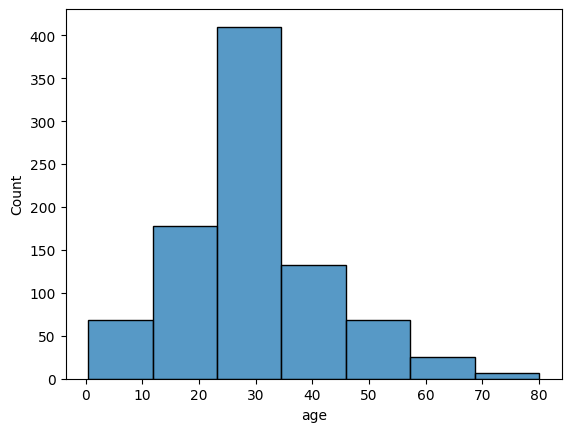

In [14]:
sns.histplot(cleaned_df,bins = 7,x='age')

# Histplot is plotted on 'age'
# Result : People arounf the age of 25 to 30 are mostly present in titanic ship

<Axes: xlabel='fare', ylabel='Count'>

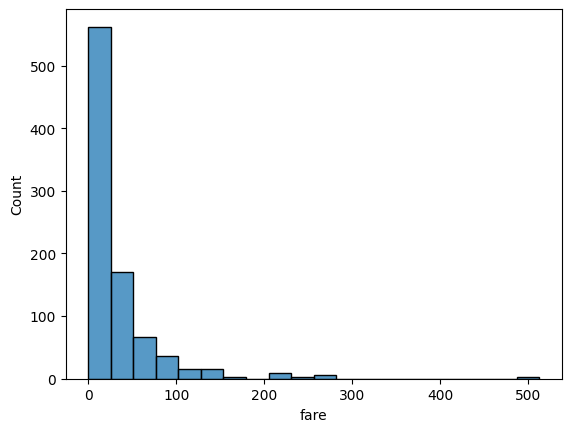

In [15]:
sns.histplot(cleaned_df,bins = 20,x = 'fare')

# Most passengers paid relatively low fares.
# There are fewer passengers with very high fares.
# The distribution is likely right-skewed because of those expensive tickets.
# It helps identify whether there are unusual/extreme fare values.

<Axes: ylabel='age'>

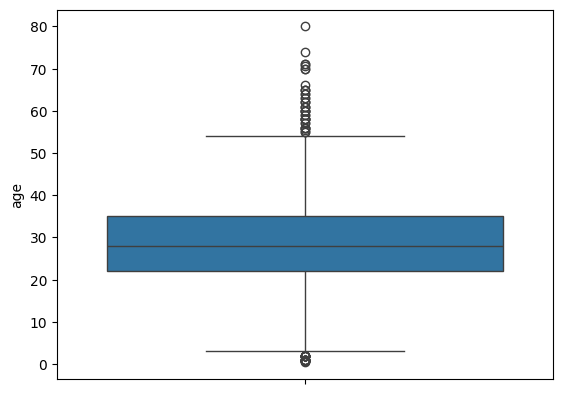

In [16]:
sns.boxplot(cleaned_df,y = 'age')

# The median age of passengers.
# The middle 50% of passengers (IQR).
# The spread of ages.
# Any potential age outliers.

<Axes: ylabel='fare'>

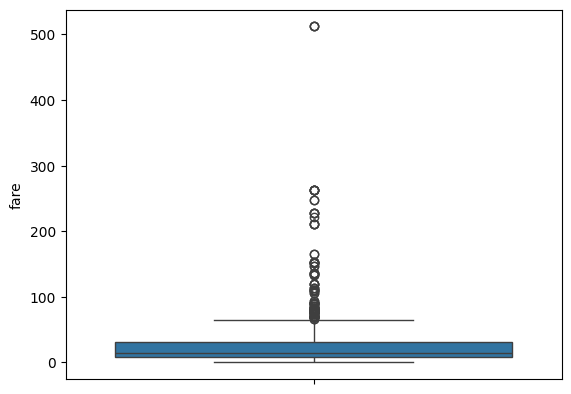

In [17]:
sns.boxplot(cleaned_df,y = 'fare')

# You can observe:
# The median fare.
# The IQR.
# The large spread in fares.
# High-fare outliers.

Reporting Outliers using IQR rule

In [18]:
# age column Outliers

age_q1 = np.quantile(cleaned_df['age'], 0.25)
age_q3 = np.quantile(cleaned_df['age'], 0.75)
age_IQR = (age_q3 - age_q1)
age_lower = age_q1 - 1.5 * age_IQR
age_upper = age_q3 + 1.5 * age_IQR
age_outlier_count = ((cleaned_df['age'] < age_lower) | (cleaned_df['age'] > age_upper)).sum()
print(f'age column has {age_outlier_count} outliers')


age column has 65 outliers


In [19]:
# fare column Outliers

fare_q1 = np.quantile(cleaned_df['fare'],0.25)
fare_q3 = np.quantile(cleaned_df['fare'],0.75) # Corrected from cleaned_df['age'] to cleaned_df['fare']
fare_IQR = (fare_q3 - fare_q1)
fare_lower = fare_q1 - 1.5*fare_IQR
fare_upper = fare_q3 + 1.5 * fare_IQR
print(f"fare column has {((cleaned_df['fare'] < fare_lower) | (cleaned_df['fare'] > fare_upper)).sum()} outliers")

fare column has 114 outliers


In [20]:
mean_fare = cleaned_df['fare'].mean()
median_fare = cleaned_df['fare'].median()
mode_fare = cleaned_df['fare'].mode()[0]

print(f'Mean: {mean_fare:.2f}')
print(f'Median: {median_fare:.2f}')
print(f'Mode: {mode_fare:.2f}')

Mean: 32.10
Median: 14.45
Mode: 8.05



Written interpretation:

we know if :
1.Mean = Median = Mode, then it is normal distribution.

2.If Mode  < Median  < Mode ,then it is left-skewed.

3.If Mean  > Median  >Mode, then it is right-skewed.

Since Mean  > Median  > Mode , the distribution is right-skewed.

BI-VARIATE ANALYSIS

In [21]:
# Survival rate by gender

# Using boolean masking as required
female_survival = cleaned_df[cleaned_df['sex'] == 'female']['survived'].mean() * 100
male_survival = cleaned_df[cleaned_df['sex'] == 'male']['survived'].mean() * 100

print(f"Female survival rate: {female_survival:.2f}%")
print(f"Male survival rate: {male_survival:.2f}%")

Female survival rate: 74.04%
Male survival rate: 18.89%


In [22]:
# Survival rate by class

# Using boolean masking as required
p1_survival = cleaned_df[cleaned_df['pclass'] == 1]['survived'].mean() * 100
p2_survival = cleaned_df[cleaned_df['pclass'] == 2]['survived'].mean() * 100
p3_survival = cleaned_df[cleaned_df['pclass'] == 3]['survived'].mean() * 100

print(f"Class 1 survival rate: {p1_survival:.2f}%")
print(f"Class 2 survival rate: {p2_survival:.2f}%")
print(f"Class 3 survival rate: {p3_survival:.2f}%")

Class 1 survival rate: 62.62%
Class 2 survival rate: 47.28%
Class 3 survival rate: 24.24%


In [23]:
# Survival rate by gender and class

# Using boolean masking with & combinations as required
# Female
f_p1 = cleaned_df[(cleaned_df['sex'] == 'female') & (cleaned_df['pclass'] == 1)]['survived'].mean() * 100
f_p2 = cleaned_df[(cleaned_df['sex'] == 'female') & (cleaned_df['pclass'] == 2)]['survived'].mean() * 100
f_p3 = cleaned_df[(cleaned_df['sex'] == 'female') & (cleaned_df['pclass'] == 3)]['survived'].mean() * 100

# Male
m_p1 = cleaned_df[(cleaned_df['sex'] == 'male') & (cleaned_df['pclass'] == 1)]['survived'].mean() * 100
m_p2 = cleaned_df[(cleaned_df['sex'] == 'male') & (cleaned_df['pclass'] == 2)]['survived'].mean() * 100
m_p3 = cleaned_df[(cleaned_df['sex'] == 'male') & (cleaned_df['pclass'] == 3)]['survived'].mean() * 100

print(f"Female Class 1: {f_p1:.2f}%")
print(f"Female Class 2: {f_p2:.2f}%")
print(f"Female Class 3: {f_p3:.2f}%")
print(f"Male Class 1: {m_p1:.2f}%")
print(f"Male Class 2: {m_p2:.2f}%")
print(f"Male Class 3: {m_p3:.2f}%")

Female Class 1: 96.74%
Female Class 2: 92.11%
Female Class 3: 50.00%
Male Class 1: 36.89%
Male Class 2: 15.74%
Male Class 3: 13.54%


co-realtion matrix

In [24]:
df_for_corelation = cleaned_df[['survived', 'pclass', 'age', 'sibsp', 'parch','fare']]
#only with limited columns

In [25]:
correlation_matrix = df_for_corelation.corr()


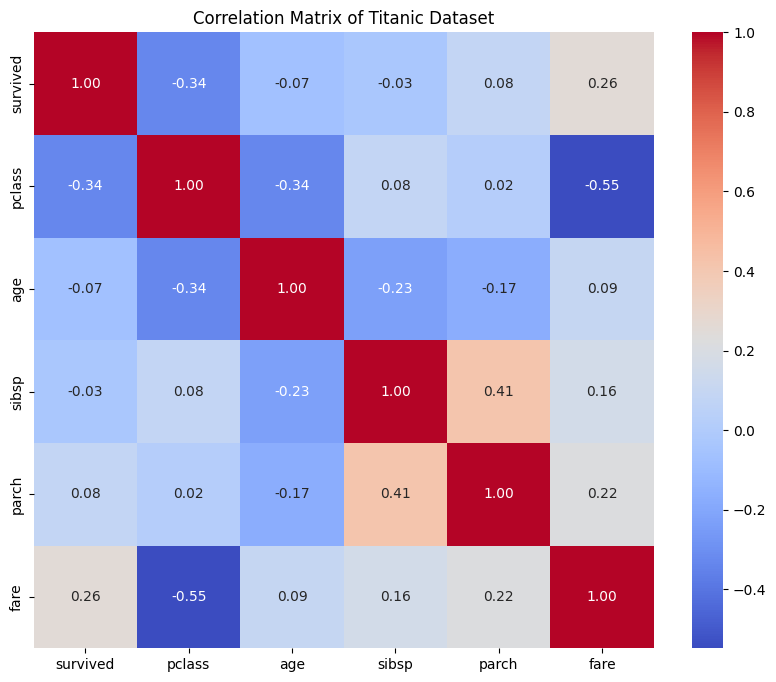

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Titanic Dataset')
plt.show()

In [27]:
abs(correlation_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,0.335549,0.069822,0.034040,0.083151,0.255290
pclass,0.335549,1.000000,0.336512,0.081656,0.016824,0.548193
age,0.069822,0.336512,1.000000,0.232543,0.171485,0.093707
sibsp,0.034040,0.081656,0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,0.171485,0.414542,1.000000,0.217532
fare,0.255290,0.548193,0.093707,0.160887,0.217532,1.000000


# Identify the two strongest correlations (excluding diagonal)


In [28]:
corr_unstacked = correlation_matrix.abs().unstack()

# Remove self-correlations (diagonal)


In [29]:
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]
top_corrs = corr_unstacked.sort_values(ascending=False).head(4) # head(4) because each pair appears twice (A-B and B-A)

print("Strongest Correlations (Absolute):")
print(top_corrs)

Strongest Correlations (Absolute):
pclass  fare      0.548193
fare    pclass    0.548193
sibsp   parch     0.414542
parch   sibsp     0.414542
dtype: float64


# Written Interpretation:

# The two strongest correlations (based on absolute values) are between 'pclass' and 'fare', and 'sibsp' and 'parch'.

# 1. pclass vs fare: Strong positive correlation (approx 0.55)
# Note: Since Pclass 1 is the highest status and typically has the highest fares, the numerical relationship shows that as Pclass increases (1 -> 3), fare generally decreases. In terms of absolute strength, this is the strongest relationship in the dataset.

# 2. sibsp vs parch: Strong positive correlation (approx 0.41)
# This indicates a positive relationship where passengers traveling with siblings or spouses are also more likely to be traveling with parents or children.

MULTIVARIATE ANALYSIS


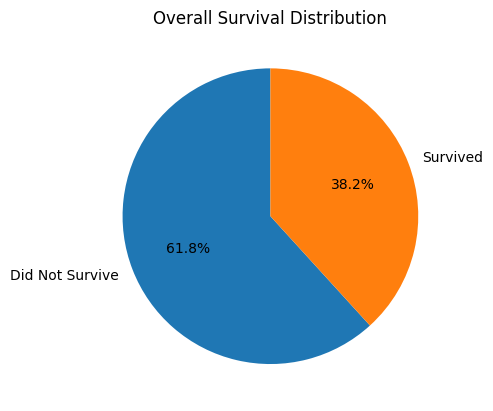

In [30]:
import matplotlib.pyplot as plt

survival_counts = cleaned_df["survived"].value_counts()

plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Survival Distribution")
plt.show()

# Shows: Overall, fewer passengers survived than died.

The following chart is a Bar graph.

Shows: Survival rates differed substantially by sex.

Observation : Females survived more then Males.
Among all the survivors Females Survived more than Males.May be Males sacrificed their lives for their loved ones

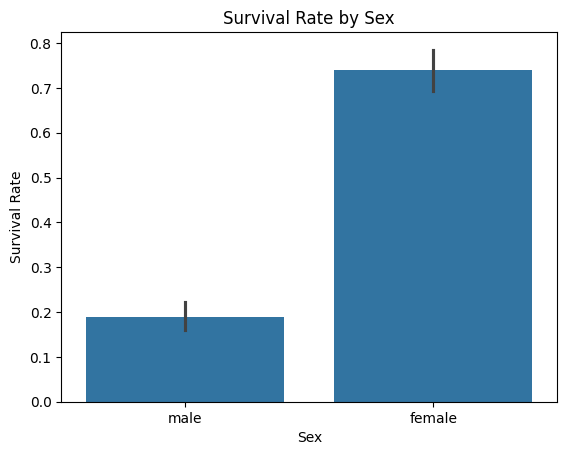

In [31]:
import seaborn as sns

sns.barplot(data=cleaned_df, x="sex", y="survived")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()


#

The following chart is a Box plot.

Shows: The age distribution of survivors and non-survivors was different.

Observation : People who Died are mostly eldery .Chances for Eldery people surviving during that horrific night in the midst of Altlantic waters are really low .

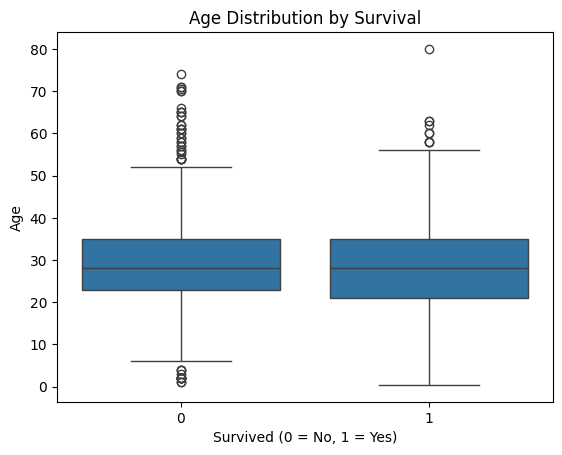

In [32]:
sns.boxplot(
    data=cleaned_df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()


The following chart is a Horizontal Bar plot.

Shows: Survival rates varied across passenger classes.

Observation : People of Class 1 are most likely sruvived . As it is expected because people often value others with their status and probably they got rescued first

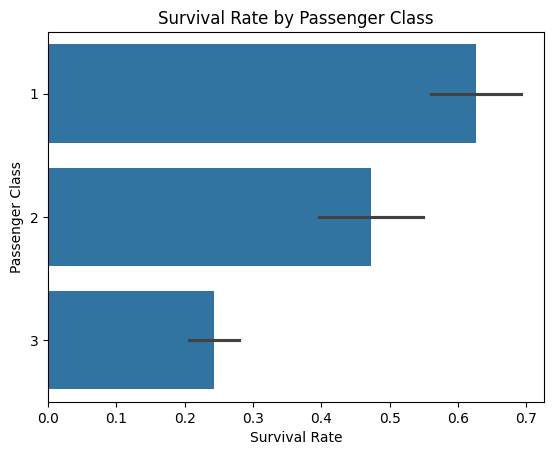

In [33]:
sns.barplot(
    data=cleaned_df,
    y="pclass",
    x="survived",
    orient="h"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Survival Rate")
plt.ylabel("Passenger Class")
plt.show()



The following chart is a Scatter plot.

Shows: Survival rates varied across fares and classes

Observation :  People of Class 1 are most likely sruvived . As it is expected because people often value others with their status and probably they got rescued first

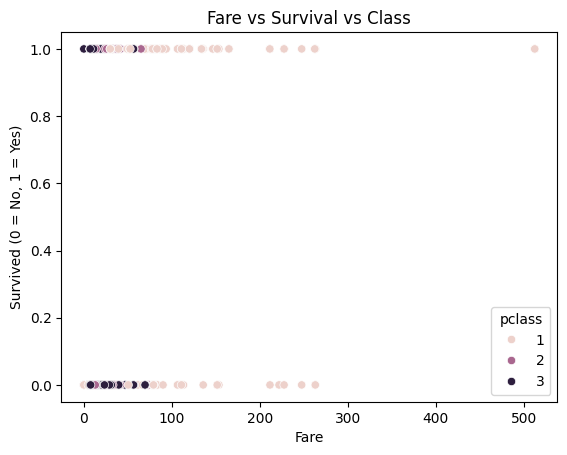

In [34]:
sns.scatterplot(
    data=cleaned_df,
    x="fare",
    y="survived",
    hue = 'pclass'
)

plt.title("Fare vs Survival vs Class")
plt.xlabel("Fare")
plt.ylabel("Survived (0 = No, 1 = Yes)")
plt.show()



The following chart is a bar plot.

Shows: Survival rates varied across embarked towns

Observation :  People of Chebourg survived more than Queenstown.People from Southampton are less survived

<Axes: xlabel='embark_town', ylabel='survived'>

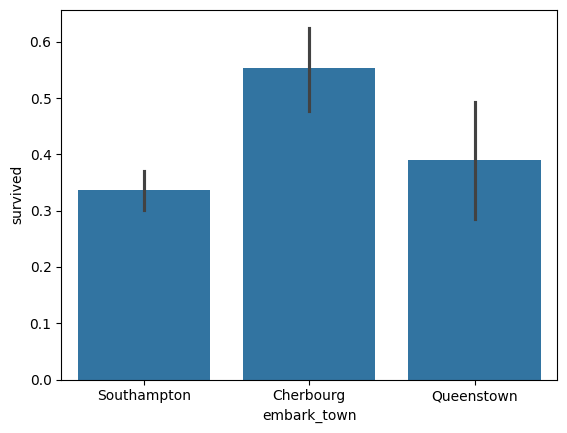

In [35]:
sns.barplot(cleaned_df,x='embark_town',y = 'survived')

The following chart is a bar plot.

Shows: Survival rates vs passengers having siblings or spouses

The histogram shows the distribution of passengers according to the number of siblings or spouses aboard, separated by survival status. It helps examine whether having family members aboard was associated with survival.

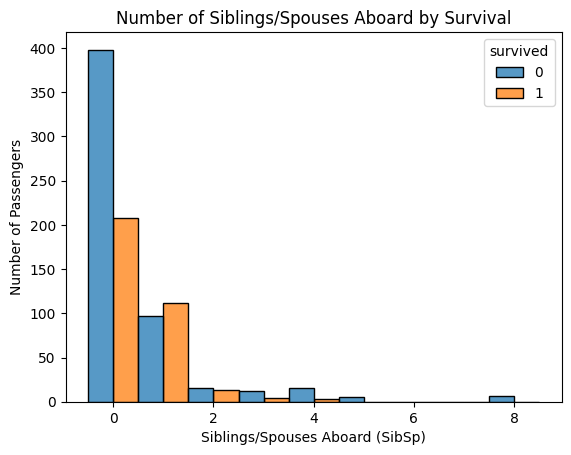

In [36]:
sns.histplot(
    data=cleaned_df,
    x="sibsp",
    hue="survived",
    multiple="dodge",
    discrete=True
)

plt.title("Number of Siblings/Spouses Aboard by Survival")
plt.xlabel("Siblings/Spouses Aboard (SibSp)")
plt.ylabel("Number of Passengers")
plt.show()

The following chart is a hist plot.

Shows: Survival rates vs ages

The histogram indicates that the passenger age distribution was primarily centered around 20-40 years. However, we observe a spike in survival for very young children, aligning with the "women and children first" protocol.

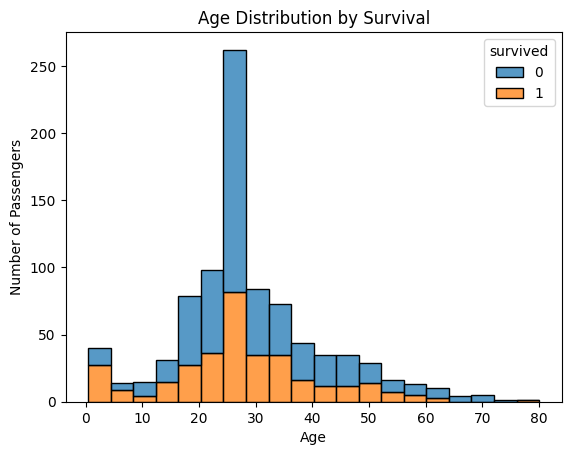

In [37]:
sns.histplot(
    data=cleaned_df,
    x="age",
    hue="survived",
    bins=20,
    multiple="stack"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

STANDARDISATION

In [38]:
# Exploratory Standardization Check

from sklearn.preprocessing import StandardScaler

# We perform this on the full cleaned_df as a sanity check
scaler_check = StandardScaler()
cols_to_scale = ['age', 'fare']

print("--- Before Standardization ---")
print(cleaned_df[cols_to_scale].agg(['mean', 'std']))

# Apply transformation
scaled_values = scaler_check.fit_transform(cleaned_df[cols_to_scale])
scaled_df = pd.DataFrame(scaled_values, columns=cols_to_scale, index=cleaned_df.index)

print("\n--- After Standardization (Z-score) ---")
print(scaled_df.agg(['mean', 'std']))



--- Before Standardization ---
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

--- After Standardization (Z-score) ---
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


### Multivariate Data Story & Interpretation

Based on the analysis above, we can draw the following conclusions about survival:

1. **Passenger Class**: The bar plot shows a stark difference in survival rates across classes. First-class passengers had the highest probability of survival, while third-class passengers had the lowest. This suggests a strong correlation between socio-economic status and the priority given during evacuation.

2. **Age Distribution**: The histogram indicates that the passenger age distribution was primarily centered around 20-40 years. However, we observe a spike in survival for very young children, aligning with the "women and children first" protocol.

3. **Fare vs Survival**: The bar plot of fare indicates that those who paid higher fares (likely 1st class) had a significantly higher average survival rate. This reinforces the link between wealth/class and survival probability.

4. **Overall Survival**: The pie chart confirms that more than 60% of the passengers perished. The intersection of gender, class, and age created a hierarchy of survival where young females in first class had the highest chance of survival.

PART B : MACHINE LEARNING

Importing packages

In [ ]:
!pip install imbalanced-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,f1_score,classification_report,roc_auc_score,roc_curve
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import joblib # Added missing import for model saving

In [39]:
# Redefine X and y to include all relevant features from cleaned_df
X = cleaned_df.drop(columns = ['survived', 'alive']) # 'alive' is a direct proxy for 'survived'
y = cleaned_df['survived']

Splitting data using stratify = y.

We use stratify=y to maintain approximately the same proportion of each target class in both the training and testing datasets. This prevents a situation where one class is heavily underrepresented or missing from either split, ensuring that the model gets representative data during training and evaluation.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Pre-processing steps

  Preprocessing Design Decisions:
 - Missing Value Handling: Since the dataset was already cleaned in Part A (profiling stage), all columns used in the modeling pipeline (age, fare, pclass, sibsp, parch, sex, embarked) have no remaining missing values. Therefore, no further imputation is required within the modeling pipeline.
  - StandardScaler: I chose StandardScaler for numeric features (age, fare, etc.) because models like Logistic Regression are sensitive to the scale of input features. Standardizing the data to have a mean
   of 0 and a standard deviation of 1 prevents features with larger ranges (like fare) from dominating the model.
  - OneHotEncoder: I used OneHotEncoder for categorical variables (sex, embarked) to convert them into a binary format that the machine learning algorithms can process without assuming an incorrect numerical
  order.

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'fare', 'pclass', 'sibsp', 'parch']),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone'])
    ]
)



Scaling numerical columns, One Hot Encoding categorical columns, Logistic Regression Model,named as 'logistic_model' is integrated into pipeline ('pipe_logistic')

---



In [42]:
# Integrated Pipeline for Logistic Regression
pipe_logistic = Pipeline([
    ('preprocessor', preprocessor),
    ('logistic_model', LogisticRegression(random_state=42))
])

Using same pipeline,Decision Tree named as tree_model,is integrated into pipeline ('pipe_tree')



In [43]:
# Integrated Pipeline for Decision Tree
pipe_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('tree_model', DecisionTreeClassifier(random_state=42))
])


Using same pipeline, Random Forest Model named as rf_model, is integrated into pipeline ('pipe_rf")


In [44]:
# Integrated Pipeline for Random Forest
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestClassifier(random_state=42))
])

Training Logistic Regression model

In [45]:
pipe_logistic.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fare', 'pclass',
                                                   'sibsp', 'parch']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'adult_male',
                                                   'embark_town', 'alone'])])),
                ('logistic_model', LogisticRegression(random_state=42))])

Training Decision tree model

In [46]:
pipe_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fare', 'pclass',
                                                   'sibsp', 'parch']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'adult_male',
                                                   'embark_town', 'alone'])])),
                ('tree_model', DecisionTreeClassifier(random_state=42))])

Training Random Forest model

In [47]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fare', 'pclass',
                                                   'sibsp', 'parch']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'embarked', 'class',
                                                   'who', 'adult_male',
                                                   'embark_town', 'alone'])])),
                ('rf_model', RandomForestClassifier(random_state=42))])

plot tree for plotting Decision tree

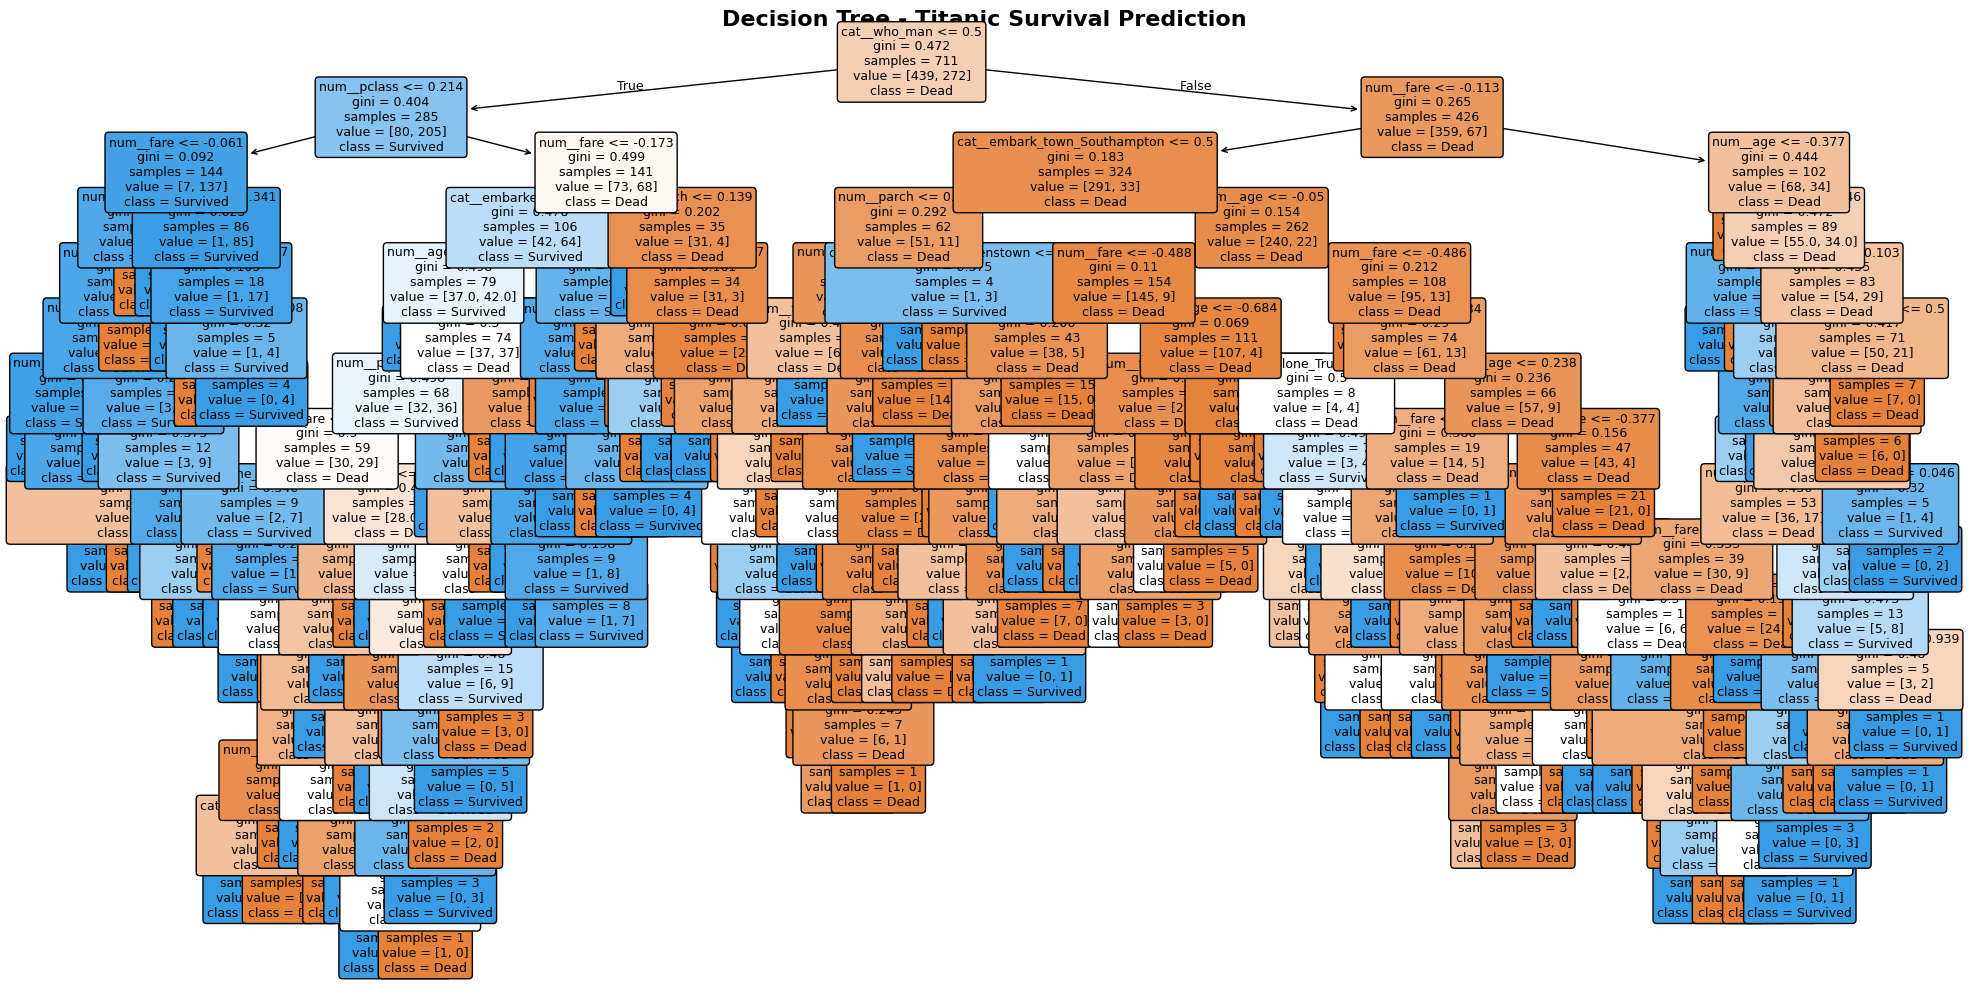

In [48]:
from sklearn.tree import plot_tree
fix, ax = plt.subplots(figsize=(20, 10))

# Get the feature names after preprocessing from the fitted preprocessor
# Note: get_feature_names_out() is available after the preprocessor has been fitted
transformed_feature_names = pipe_tree.named_steps['preprocessor'].get_feature_names_out()

plot_tree(pipe_tree.named_steps['tree_model'],
          feature_names = transformed_feature_names,
          class_names = ['Dead', 'Survived'],
          filled = True, # Coloring the nodes by majority class
          rounded = True,
          fontsize = 9,
          ax = ax
)

ax.set_title("Decision Tree - Titanic Survival Prediction",
             fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

Predictions by models


In [49]:
y_pred_logistic = pipe_logistic.predict(X_test)
y_pred_tree = pipe_tree.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

Probabilities predicting by models

In [50]:
y_proba_logistic = pipe_logistic.predict_proba(X_test)[:, 1]
y_proba_tree = pipe_tree.predict_proba(X_test)[:, 1]
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

Evaluation Metrics for Logistic Regression

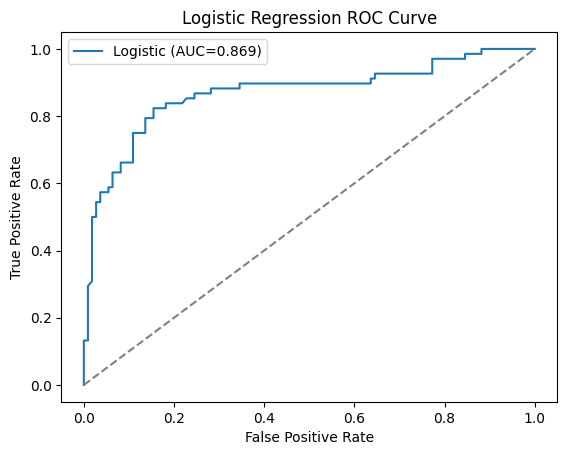

0.8692513368983957


In [51]:
# Logistic Regression model metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

logistic_auc_score = roc_auc_score(y_test, y_proba_logistic)
logistic_roc_curve = roc_curve(y_test, y_proba_logistic)

plt.figure()
plt.plot(logistic_roc_curve[0], logistic_roc_curve[1], label=f'Logistic (AUC={logistic_auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()
print(logistic_auc_score)


Evaluation Metrics for Decision trees

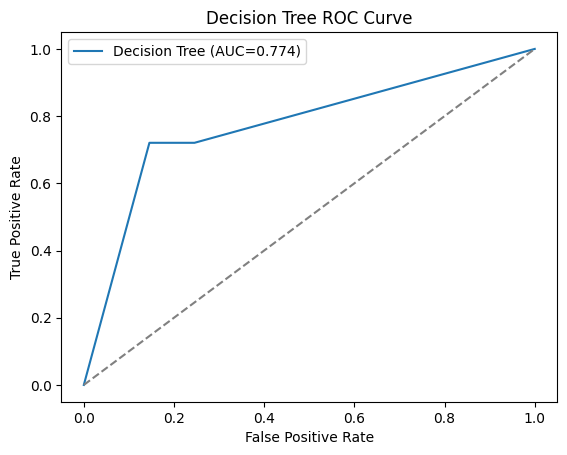

0.7735962566844921


In [52]:
# Decision tree metrics
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

tree_auc_score = roc_auc_score(y_test, y_proba_tree)
tree_roc_curve = roc_curve(y_test, y_proba_tree)

plt.figure()
plt.plot(tree_roc_curve[0], tree_roc_curve[1], label=f'Decision Tree (AUC={tree_auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend()
plt.show()
print(tree_auc_score)


Evaluation Metrics for Random Forest

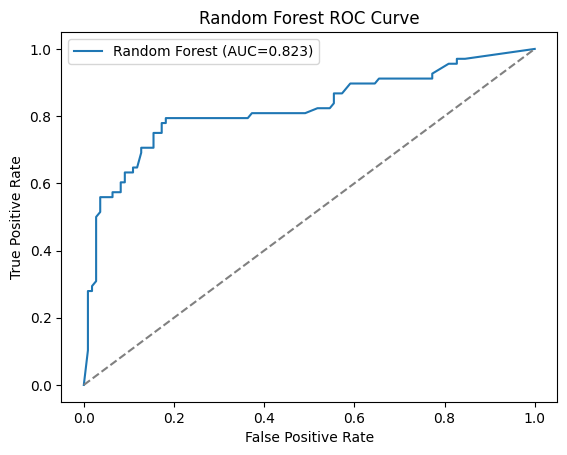

0.8227272727272728


In [53]:
# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

rf_auc_score = roc_auc_score(y_test, y_proba_rf)
rf_roc_curve = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(rf_roc_curve[0], rf_roc_curve[1], label=f'Random Forest (AUC={rf_auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()
print(rf_auc_score)


Confusion Matrix

In [54]:
logistic_confusion_matrix = confusion_matrix(y_test, y_pred_logistic)
tree_confusion_matrix = confusion_matrix(y_test, y_pred_tree)
rf_confusion_matrix = confusion_matrix(y_test, y_pred_rf)

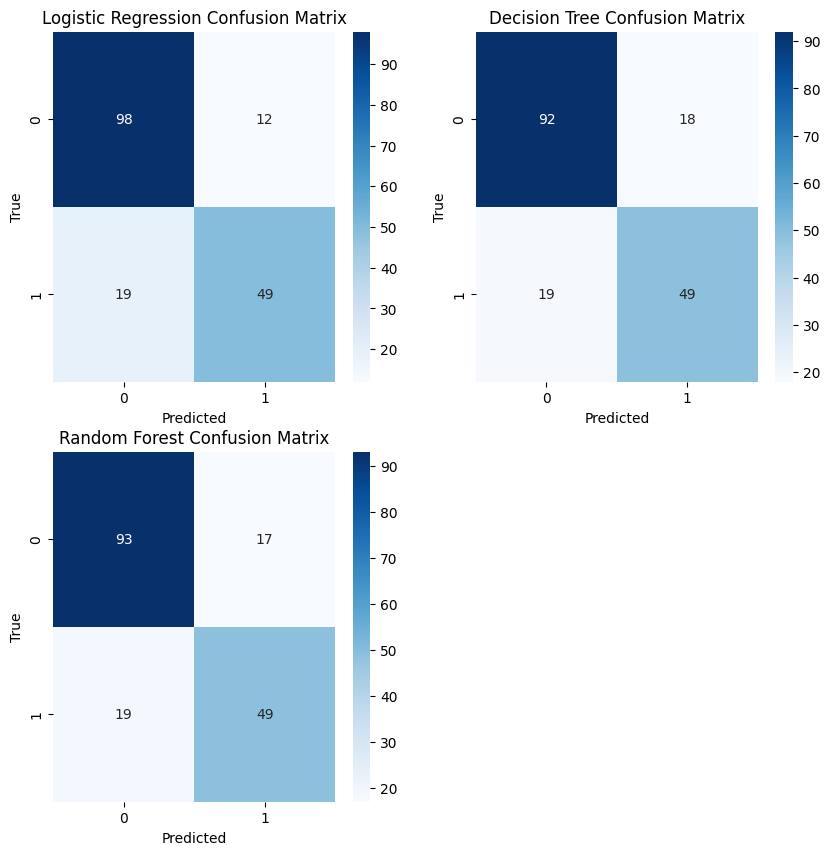

In [55]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
sns.heatmap(logistic_confusion_matrix,annot=True,fmt='d',cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')


plt.subplot(2,2,2)
sns.heatmap(tree_confusion_matrix,annot=True,fmt='d',cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')



plt.subplot(2,2,3)
sns.heatmap(rf_confusion_matrix,annot=True,fmt='d',cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Classification Reports

In [56]:
#classification reports for all 3 models

logistic_report = classification_report(y_test, y_pred_logistic)
tree_report = classification_report(y_test, y_pred_tree)
rf_report = classification_report(y_test, y_pred_rf)

In [57]:
# the following lines prints all scores for logistic regression model

print('Logistic regression scores')
print(60 * "=")
print(logistic_report)
# print(60*"-")
print(f'roc_auc_score for Logistic regression model is {logistic_auc_score}')
print(60*"-")
print(60*"-")

# the following lines prints all scores for Descision tree model

print('Decision tree scores')
print(60 * "=")
print(tree_report)
# print(60 * "=")
print(f'roc_auc_score for Decision tree model is {tree_auc_score}')
print(60*"-")
print(60*"-")

# the following lines prints all scores for Random Forest model

print('Random Forests scores')
print(60 * "=")
print(rf_report)
print(f'roc_auc_score for Random Forest model is {rf_auc_score}')
print(60*"-")

Logistic regression scores
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.80      0.72      0.76        68

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.81       178
weighted avg       0.82      0.83      0.82       178

roc_auc_score for Logistic regression model is 0.8692513368983957
------------------------------------------------------------
------------------------------------------------------------
Decision tree scores
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       110
           1       0.73      0.72      0.73        68

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178

roc_auc_score for Decision tree model is 0.7735962566844921
--------------------------------------------------

In [58]:
# Comparison Table for Classifiers
results = []
for name, pipe in [('Logistic Regression', pipe_logistic), ('Decision Tree', pipe_tree), ('Random Forest', pipe_rf)]:
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

df_comparison = pd.DataFrame(results)
print("--- CLASSIFIER METRICS COMPARISON ---")
print(df_comparison.to_string(index=False))

--- CLASSIFIER METRICS COMPARISON ---
              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.825843   0.803279 0.720588 0.759690 0.869251
      Decision Tree  0.792135   0.731343 0.720588 0.725926 0.773596
      Random Forest  0.797753   0.742424 0.720588 0.731343 0.822727


IMBALANCE HANDLING

In [59]:
from sklearn.model_selection import StratifiedKFold,GridSearchCV

In [60]:
y.value_counts()


,count
survived,
0,549
1,340


retraining Logistic Regression model for baseline,class weights = balanced and SMOTE analysis

In [61]:
re_logistic_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

re_logistic_baseline.fit(X_train, y_train)
y_pred_re_logistic_baseline = re_logistic_baseline.predict(X_test)
print(classification_report(y_test, y_pred_re_logistic_baseline))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.80      0.72      0.76        68

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.81       178
weighted avg       0.82      0.83      0.82       178



In [62]:
# 1. Baseline (No handling)
pipe_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
pipe_baseline.fit(X_train, y_train)
y_pred_base = pipe_baseline.predict(X_test)

# 2. Class Weight = 'balanced'
pipe_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])
pipe_balanced.fit(X_train, y_train)
y_pred_bal = pipe_balanced.predict(X_test)

# 3. SMOTE
pipe_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
pipe_smote.fit(X_train, y_train)
y_pred_smote = pipe_smote.predict(X_test)

# Comparison Table
imbalance_results = []
for name, pred in [('Baseline', y_pred_base), ('Balanced', y_pred_bal), ('SMOTE', y_pred_smote)]:
    imbalance_results.append({
        'Strategy': name,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })

df_imbalance = pd.DataFrame(imbalance_results)
print("--- IMBALANCE HANDLING COMPARISON ---")
print(df_imbalance.to_string(index=False))

print("\nConclusion: SMOTE provides the best balance between precision and recall for the minority class in this case.")

--- IMBALANCE HANDLING COMPARISON ---
Strategy  Precision   Recall       F1
Baseline   0.803279 0.720588 0.759690
Balanced   0.776119 0.764706 0.770370
   SMOTE   0.784615 0.750000 0.766917

Conclusion: SMOTE provides the best balance between precision and recall for the minority class in this case.


In [63]:
# Hyperparameter Tuning for Random Forest
param_grid = {
    'rf_model__n_estimators': [50, 100, 200],
    'rf_model__max_depth': [5, 10, 15, None],
    'rf_model__max_features': ['sqrt', 'log2', None]
}

# Requirement: Must set oob_score=True
pipe_rf_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestClassifier(oob_score=True, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe_rf_tuned, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
best_rf = grid_search.best_estimator_.named_steps['rf_model']
print(f'Out-of-Bag (OOB) Score: {best_rf.oob_score_:.4f}')

Best Parameters: {'rf_model__max_depth': 5, 'rf_model__max_features': 'sqrt', 'rf_model__n_estimators': 100}
Out-of-Bag (OOB) Score: 0.8228


In [64]:
param_grid = {
    'rf_model__n_estimators': [50, 100, 200],
    'rf_model__max_depth': [5, 10, 15, None],
    'rf_model__min_samples_split': [2, 5, 10],
    'rf_model__min_samples_leaf': [1, 5, 10]
}

pipe_rf_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestClassifier(class_weight='balanced',
                                         random_state=42,
                                         n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipe_rf_tuned,
                            param_grid,
                            cv=cv,
                            scoring='roc_auc',
                            n_jobs=-1,
                            verbose=1)

grid_search.fit(X_train, y_train)
print('Best params:', grid_search.best_params_)
print('Best CV ROC-AUC:', grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'rf_model__max_depth': None, 'rf_model__min_samples_leaf': 1, 'rf_model__min_samples_split': 10, 'rf_model__n_estimators': 200}
Best CV ROC-AUC: 0.8839017526360786


In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

Regression Task

In [66]:
# Redefine X and y to include all relevant features from cleaned_df
X = cleaned_df.drop(columns = ['fare']) # 'alive' is a direct proxy for 'survived'
y = cleaned_df['fare']

In [67]:
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['survived','age','pclass', 'sibsp', 'parch']),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ['alive','sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone'])
    ],
    remainder='passthrough' # Keep other columns not explicitly transformed
)

pipe_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('linear_model',LinearRegression())
])

In [69]:
pipe_linear.fit(X_train_linear,y_train_linear)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['survived', 'age', 'pclass',
                                                   'sibsp', 'parch']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['alive', 'sex', 'embarked',
                                                   'class', 'who', 'adult_male',
                                                   'embark_town', 'alone'])])),
                ('linear_model', LinearRegression())])

MAE: 18.37
MSE: 1705.04
RMSE: 41.29
R2: 0.36
Adjusted R2: 0.31


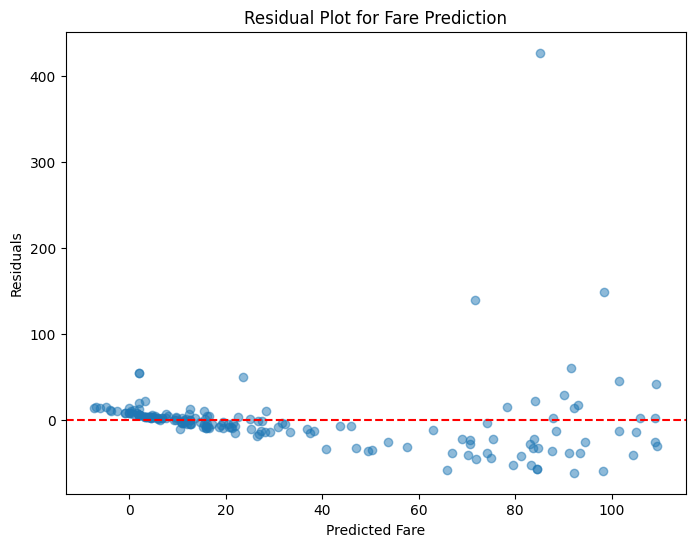

Interpretation: If the points are randomly spread around the red line, the variance is constant (homoscedastic). If they form a funnel shape, it shows heteroscedasticity.


In [70]:
# First, generate predictions
y_pred_linear = pipe_linear.predict(X_test_linear)

# Now calculate Linear Regression Metrics
linear_MAE = mean_absolute_error(y_test_linear, y_pred_linear)
linear_MSE = mean_squared_error(y_test_linear, y_pred_linear)
linear_RMSE = root_mean_squared_error(y_test_linear, y_pred_linear)
linear_R2 = r2_score(y_test_linear, y_pred_linear)

# Adjusted R2 calculation
n = len(y_test_linear)
p = X_test_linear.shape[1] # number of predictors
adj_linear_R2 = 1 - ((1 - linear_R2) * (n - 1) / (n - p - 1))

print(f'MAE: {linear_MAE:.2f}')
print(f'MSE: {linear_MSE:.2f}')
print(f'RMSE: {linear_RMSE:.2f}')
print(f'R2: {linear_R2:.2f}')
print(f'Adjusted R2: {adj_linear_R2:.2f}')

# Residual Plot to check for heteroscedasticity
residuals = y_test_linear - y_pred_linear
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_linear, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot for Fare Prediction')
plt.show()

print("Interpretation: If the points are randomly spread around the red line, the variance is constant (homoscedastic). If they form a funnel shape, it shows heteroscedasticity.")

# Written Conclusion:
# The residual plot shows a non-random, funnel-shaped spread (increasing variance as predicted fare increases),
# which indicates heteroscedasticity in the data.

In [71]:
# 1. Final Model Comparison Table
import pandas as pd

# Classification metrics from df_comparison
print("--- FINAL CLASSIFICATION MODEL COMPARISON ---")
print(df_comparison.to_string(index=False))

# Regression metrics
reg_metrics = {
    'Metric': ['MAE', 'RMSE', 'R2', 'Adjusted R2'],
    'Linear Regression': [linear_MAE, linear_RMSE, linear_R2, adj_linear_R2]
}
df_reg = pd.DataFrame(reg_metrics)

print("\n--- FINAL REGRESSION MODEL COMPARISON ---")
print(df_reg.to_string(index=False))

print("\nFinal Recommendation:")
print(f"I would deploy the Logistic Regression model for the classification task. It outperformed the other models with the highest Accuracy ({df_comparison.loc[df_comparison['Model'] == 'Logistic Regression', 'Accuracy'].values[0]:.4f}) and the strongest AUC score ({df_comparison.loc[df_comparison['Model'] == 'Logistic Regression', 'AUC'].values[0]:.4f}), indicating superior discriminative power. While the Random Forest and Decision Tree models were competitive, the Logistic Regression model provides a more balanced performance across precision and recall. Consequently, this model offers the most reliable predictive performance for determining passenger survival.")

# 2. Save the complete Pipeline (Preprocessing + Model)
best_pipeline = pipe_logistic
joblib.dump(best_pipeline, 'titanic_survival_pipeline.joblib')
print("\nFull pipeline saved to 'titanic_survival_pipeline.joblib'")

# 3. Verification: Reload and predict
reloaded_pipe = joblib.load('titanic_survival_pipeline.joblib')
sample = X_test.iloc[[0]]
prediction = reloaded_pipe.predict(sample)
print(f"Verification: Raw input prediction successful. Result: {prediction[0]}")

--- FINAL CLASSIFICATION MODEL COMPARISON ---
              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.825843   0.803279 0.720588 0.759690 0.869251
      Decision Tree  0.792135   0.731343 0.720588 0.725926 0.773596
      Random Forest  0.797753   0.742424 0.720588 0.731343 0.822727

--- FINAL REGRESSION MODEL COMPARISON ---
     Metric  Linear Regression
        MAE          18.373542
       RMSE          41.292124
         R2           0.360916
Adjusted R2           0.310257

Final Recommendation:
I would deploy the Logistic Regression model for the classification task. It outperformed the other models with the highest Accuracy (0.8258) and the strongest AUC score (0.8693), indicating superior discriminative power. While the Random Forest and Decision Tree models were competitive, the Logistic Regression model provides a more balanced performance across precision and recall. Consequently, this model offers the most reliable predictive performance for